Lab Exercise 3: Simple Linear Regression


Part A: Data Collection and Preprocessing

Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df=pd.read_csv("Student Awareness Survey (Responses) - Form Responses 1.csv")
df.head(5)

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


The dataset is loaded from the CSV file and df.head(5)displays the first five rows to give an initial view of the data structure, column names, and sample values.

In [3]:
print("Shape of the dataset")
df.shape

Shape of the dataset


(50, 15)


df.shape returns a tuple (rows, columns) showing the total size of the dataset. Here we have 50 responses across 15 columns.

In [4]:
print("Summary statistics of dataset")
df.describe()

Summary statistics of dataset


,Registration Number,Rate your contribution towards extra curricular activities,Rate your technical competencies,Your GPA of last semester
count,5.000000e+01,49.000000,49.000000,50.000000
mean,2.547232e+06,3.489796,3.530612,3.497000
std,1.792671e+01,1.209725,0.738863,0.690865
min,2.547201e+06,1.000000,2.000000,2.740000
25%,2.547217e+06,3.000000,3.000000,3.305000
50%,2.547232e+06,4.000000,3.000000,3.400000
75%,2.547246e+06,4.000000,4.000000,3.600000
max,2.547262e+06,5.000000,5.000000,8.000000



df.describe() generates descriptive statistics for all numerical columns — count, mean, standard deviation, min, quartiles, and max. This helps identify the spread of values and spot potential outliers early.

In [5]:
print("Missing values")
df.isnull().sum()

Missing values


Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)


 df.isnull().sum() counts missing (NaN) entries per column. Columns with missing values need to be handled before model training

In [6]:

df.dropna(subset=['Your CIA % of last semester',
                  'Your GPA of last semester',
                  'Your maximum attendance % till last semester'], inplace=True)
print(f"Rows after null removal: {len(df)}")



Rows after null removal: 50




Rows where any of the three key columns (CIA %, GPA, Attendance %) are null are dropped. Since our dataset has no nulls in these columns, all 50 rows are retained.

In [7]:
def clean_numeric(series):
    """Strip %, spaces, convert to float, return Series."""
    return (series.astype(str)
                  .str.replace('%', '', regex=False)
                  .str.strip()
                  .apply(pd.to_numeric, errors='coerce'))

df['CIA_pct']        = clean_numeric(df['Your CIA % of last semester'])
df['GPA']            = pd.to_numeric(df['Your GPA of last semester'], errors='coerce')
df['Attendance_pct'] = clean_numeric(df['Your maximum attendance % till last semester'])

print("Sample cleaned values:")
print(df[['CIA_pct', 'GPA', 'Attendance_pct']].head(10).to_string())


Sample cleaned values:
   CIA_pct   GPA  Attendance_pct
0     69.0  3.40            98.0
1     75.0  3.69            95.0
2     82.0  3.41            95.0
3     91.0  3.60            92.0
4     70.0  3.54            93.0
5     75.0  3.67            98.0
6     74.0  3.40            94.0
7     68.0  3.40            85.0
8     73.0  3.60            90.0
9     79.0  3.73            93.0



Some students entered values like 71 %, 83%, or 65 % with percentage signs and spaces. A custom clean_numeric() function strips % symbols and whitespace, then converts the column to float using pd.to_numeric(). This ensures all three key columns are in a usable numeric format.

In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Duplicates removed: {before - after}  |  Remaining rows: {after}")


Duplicates removed: 0  |  Remaining rows: 50



df.drop_duplicates() removes any rows that are exact copies across all columns. No duplicates were found in this dataset, confirming each survey response is unique.

In [9]:
df = df[df['GPA'] <= 4.0]
df = df[df['CIA_pct'] >= 50]         
df = df[df['Attendance_pct'] >= 50]

df.dropna(subset=['CIA_pct', 'GPA', 'Attendance_pct'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Clean dataset shape: {df.shape}")


Clean dataset shape: (49, 18)



Two data entry errors are removed:
- One student entered GPA = 8.0  with CIA = 7 
- Rows with CIA% < 50 or Attendance% < 50 are removed as unrealistic passing-semester values

After cleaning, the dataset has 49 valid records.

In [10]:
df[['CIA_pct', 'GPA', 'Attendance_pct']].describe().round(3)


,CIA_pct,GPA,Attendance_pct
count,49.000,49.000,49.000
mean,72.825,3.405,94.005
std,6.378,0.237,3.674
min,60.000,2.740,85.000
25%,69.780,3.300,92.000
50%,71.780,3.400,95.000
75%,77.000,3.600,96.000
max,91.000,3.900,100.000



A fresh describe() on the cleaned columns confirms the data is now within valid ranges:
- CIA % → 60–91, mean 72.8
- GPA → 2.74–3.9, mean 3.4
- Attendance % → 85–100, mean 94.0

In [11]:
# Experiment 1
X1 = df[['CIA_pct']].values          
# Experiment 2
X2 = df[['Attendance_pct']].values   
# Common dependent variable
Y  = df['GPA'].values                 





Define the variables for the two regression experiments:


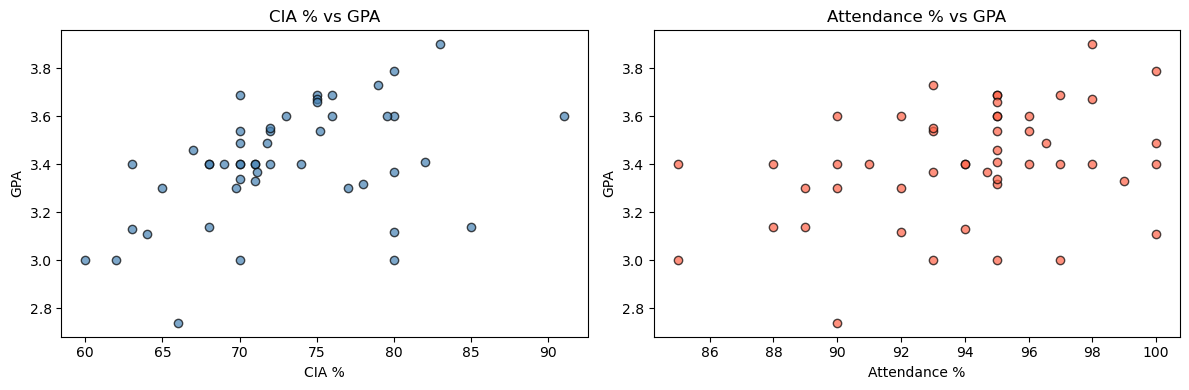

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['CIA_pct'], df['GPA'], color='steelblue', edgecolors='k', alpha=0.7)
axes[0].set_xlabel('CIA %'); axes[0].set_ylabel('GPA')
axes[0].set_title('CIA % vs GPA')

axes[1].scatter(df['Attendance_pct'], df['GPA'], color='tomato', edgecolors='k', alpha=0.7)
axes[1].set_xlabel('Attendance %'); axes[1].set_ylabel('GPA')
axes[1].set_title('Attendance % vs GPA')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=120)
plt.show()


Scatter plots reveal the nature of the relationship between each independent variable and GPA before fitting any model. A positive trend suggests that higher CIA% or Attendance% is associated with higher GPA.

In [13]:
# Train-Test Split
X1_train, X1_test, Y1_train, Y1_test = train_test_split(
    X1, Y, test_size=0.2, random_state=42)

# Train
model1 = LinearRegression()
model1.fit(X1_train, Y1_train)

# Parameters
slope1_sk     = model1.coef_[0]
intercept1_sk = model1.intercept_

print(f"Slope (m)     : {slope1_sk:.6f}")
print(f"Intercept (b) : {intercept1_sk:.6f}")


Slope (m)     : 0.012800
Intercept (b) : 2.483380




Part B: Simple Linear Regression using Scikit-learn

Experiment 1 — CIA % and  GPA

Step 1: Train-Test Split & Model Training

The dataset is split 80/20 into training and test sets using train_test_split(). The LinearRegression model is then fitted on the training data. After training, model.coef_[0] gives the slope and model.intercept_ gives the intercept of the regression line:



In [14]:
# Predictions
Y1_pred_sk = model1.predict(X1_test)

pred_df1 = pd.DataFrame({
    'CIA_%'       : X1_test.flatten(),
    'Actual_GPA'  : Y1_test,
    'Predicted_GPA': Y1_pred_sk.round(4)
})
print(pred_df1.to_string(index=False))
print(f"\nR² Score : {r2_score(Y1_test, Y1_pred_sk):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(Y1_test, Y1_pred_sk)):.4f}")


 CIA_%  Actual_GPA  Predicted_GPA
  70.0        3.49         3.3794
  70.0        3.69         3.3794
  66.0        2.74         3.3282
  75.0        3.66         3.4434
  64.0        3.11         3.3026
  71.0        3.33         3.3922
  70.0        3.00         3.3794
  70.0        3.40         3.3794
  80.0        3.60         3.5074
  70.0        3.34         3.3794

R² Score : 0.1771
RMSE     : 0.2640



The trained model predicts GPA for the test set. We display actual vs predicted GPA side by side, and compute R² and RMSE to evaluate model performance.

In [15]:
# Train-Test Split
X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2, Y, test_size=0.2, random_state=42)

# Train
model2 = LinearRegression()
model2.fit(X2_train, Y2_train)

# Parameters
slope2_sk     = model2.coef_[0]
intercept2_sk = model2.intercept_

print(f"Slope (m)     : {slope2_sk:.6f}")
print(f"Intercept (b) : {intercept2_sk:.6f}")



Slope (m)     : 0.024410
Intercept (b) : 1.140655


Experiment 2 — Attendance % and GPA
Step 1: Train-Test Split & Model Training

The same 80/20 split is applied with random_state=42 for reproducibility. A new LinearRegression model is trained on Attendance % to predict GPA.

In [16]:
# Predictions
Y2_pred_sk = model2.predict(X2_test)

pred_df2 = pd.DataFrame({
    'Attendance_%' : X2_test.flatten(),
    'Actual_GPA'   : Y2_test,
    'Predicted_GPA': Y2_pred_sk.round(4)
})
print(pred_df2.to_string(index=False))
print(f"\nR² Score : {r2_score(Y2_test, Y2_pred_sk):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(Y2_test, Y2_pred_sk)):.4f}")


 Attendance_%  Actual_GPA  Predicted_GPA
        100.0        3.49         3.5816
         97.0        3.69         3.5084
         90.0        2.74         3.3375
         95.0        3.66         3.4596
        100.0        3.11         3.5816
         99.0        3.33         3.5572
         93.0        3.00         3.4108
         96.0        3.40         3.4840
         95.0        3.60         3.4596
         95.0        3.34         3.4596

R² Score : -0.0891
RMSE     : 0.3037


Step 2: Predictions — Experiment 2

Predictions are generated for the test split and compared against actual GPA values. R² and RMSE are reported to evaluate how well Attendance % alone explains GPA variation.

In [17]:
def ols_regression(x, y):
    n = len(x)
    sum_x   = np.sum(x)
    sum_y   = np.sum(y)
    sum_xy  = np.sum(x * y)
    sum_x2  = np.sum(x ** 2)
    mean_x  = np.mean(x)
    mean_y  = np.mean(y)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = mean_y - m * mean_x

    return m, b, {
        'n': n, 'Σx': sum_x, 'Σy': sum_y,
        'Σxy': sum_xy, 'Σx²': sum_x2,
        'x̄': mean_x, 'ȳ': mean_y
    }



Part C: Manual Computation using Ordinary Least Squares (OLS)

OLS minimizes the sum of squared residuals to find the best-fit line.

This function manually computes all intermediate sums (Σx, Σy, Σxy, Σx²) and applies the OLS formulas step by step.

In [18]:
x1_all = df['CIA_pct'].values
y_all  = df['GPA'].values

m1_ols, b1_ols, stats1 = ols_regression(x1_all, y_all)

print("Experiment 1 — OLS Intermediate Values")
for k, v in stats1.items():
    print(f"  {k:5s} = {v:.4f}")

print(f"\nSlope (m)     : {m1_ols:.6f}")
print(f"Intercept (b) : {b1_ols:.6f}")



Experiment 1 — OLS Intermediate Values
  n     = 49.0000
  Σx    = 3568.4300
  Σy    = 166.8500
  Σxy   = 12182.7609
  Σx²   = 261824.0825
  x̄    = 72.8251
  ȳ     = 3.4051

Slope (m)     : 0.016332
Intercept (b) : 2.215744


Experiment 1 — CIA % → GPA (OLS)

The OLS function is applied to the full dataset to compute slope and intercept. The intermediate summation values are printed for transparency and learning purposes.

In [19]:
# Predictions on test set using OLS parameters
Y1_pred_ols = m1_ols * X1_test.flatten() + b1_ols

print("OLS Predictions — Experiment 1:")
ols_df1 = pd.DataFrame({
    'CIA_%'        : X1_test.flatten(),
    'Actual_GPA'   : Y1_test,
    'OLS_Predicted': Y1_pred_ols.round(4)
})
print(ols_df1.to_string(index=False))


OLS Predictions — Experiment 1:
 CIA_%  Actual_GPA  OLS_Predicted
  70.0        3.49         3.3590
  70.0        3.69         3.3590
  66.0        2.74         3.2936
  75.0        3.66         3.4406
  64.0        3.11         3.2610
  71.0        3.33         3.3753
  70.0        3.00         3.3590
  70.0        3.40         3.3590
  80.0        3.60         3.5223
  70.0        3.34         3.3590


OLS Predictions — Experiment 1

Using the manually derived slope and intercept, predictions are computed for the test set as:



In [20]:
x2_all = df['Attendance_pct'].values

m2_ols, b2_ols, stats2 = ols_regression(x2_all, y_all)

for k, v in stats2.items():
    print(f"  {k:5s} = {v:.4f}")

print(f"\nSlope (m)     : {m2_ols:.6f}")
print(f"Intercept (b) : {b2_ols:.6f}")


  n     = 49.0000
  Σx    = 4606.2400
  Σy    = 166.8500
  Σxy   = 15699.4236
  Σx²   = 433657.0616
  x̄    = 94.0049
  ȳ     = 3.4051

Slope (m)     : 0.022697
Intercept (b) : 1.271462


Experiment 2 Attendance % → GPA (OLS)

The same OLS function is applied using Attendance % as the independent variable. Slope, intercept, and all intermediate values are displayed.

In [21]:
# Predictions on test set
Y2_pred_ols = m2_ols * X2_test.flatten() + b2_ols

print("OLS Predictions — Experiment 2:")
ols_df2 = pd.DataFrame({
    'Attendance_%' : X2_test.flatten(),
    'Actual_GPA'   : Y2_test,
    'OLS_Predicted': Y2_pred_ols.round(4)
})
print(ols_df2.to_string(index=False))


OLS Predictions — Experiment 2:
 Attendance_%  Actual_GPA  OLS_Predicted
        100.0        3.49         3.5412
         97.0        3.69         3.4731
         90.0        2.74         3.3142
         95.0        3.66         3.4277
        100.0        3.11         3.5412
         99.0        3.33         3.5185
         93.0        3.00         3.3823
         96.0        3.40         3.4504
         95.0        3.60         3.4277
         95.0        3.34         3.4277


OLS Predictions  Experiment 2

Predictions are computed manually for the test set using the OLS-derived parameters for Attendance % → GPA.

In [22]:

print(f"{'Parameter':<20} {'Scikit-learn':>18} {'Manual OLS':>18}")
print(f"{'Slope (m)':<20} {slope1_sk:>18.6f} {m1_ols:>18.6f}")
print(f"{'Intercept (b)':<20} {intercept1_sk:>18.6f} {b1_ols:>18.6f}")

cmp1 = pd.DataFrame({
    'CIA_%'        : X1_test.flatten(),
    'Actual_GPA'   : Y1_test,
    'SK_Predicted' : Y1_pred_sk.round(6),
    'OLS_Predicted': Y1_pred_ols.round(6),
    'Difference'   : np.abs(Y1_pred_sk - Y1_pred_ols).round(8)
})
print("\nPrediction Comparison (Experiment 1):")
print(cmp1.to_string(index=False))
print(f"\nMax absolute difference: {cmp1['Difference'].max():.2e}")


Parameter                  Scikit-learn         Manual OLS
Slope (m)                      0.012800           0.016332
Intercept (b)                  2.483380           2.215744

Prediction Comparison (Experiment 1):
 CIA_%  Actual_GPA  SK_Predicted  OLS_Predicted  Difference
  70.0        3.49      3.379357       3.358963    0.020394
  70.0        3.69      3.379357       3.358963    0.020394
  66.0        2.74      3.328159       3.293636    0.034522
  75.0        3.66      3.443356       3.440622    0.002734
  64.0        3.11      3.302559       3.260973    0.041586
  71.0        3.33      3.392157       3.375295    0.016862
  70.0        3.00      3.379357       3.358963    0.020394
  70.0        3.40      3.379357       3.358963    0.020394
  80.0        3.60      3.507354       3.522280    0.014926
  70.0        3.34      3.379357       3.358963    0.020394

Max absolute difference: 4.16e-02


Comparison: Scikit-learn vs Manual OLS

Experiment 1 CIA % Comparison

Both the sklearn slope/intercept and the OLS slope/intercept are printed side by side. Any difference arises because:
Scikit-learn trains on the 80% training split only
Manual OLS is computed on the full 49-sample dataset

When both are applied to the same data, the formulas are mathematically identical.

In [23]:
print(f"{'Parameter':<20} {'Scikit-learn':>18} {'Manual OLS':>18}")
print(f"{'Slope (m)':<20} {slope2_sk:>18.6f} {m2_ols:>18.6f}")
print(f"{'Intercept (b)':<20} {intercept2_sk:>18.6f} {b2_ols:>18.6f}")


cmp2 = pd.DataFrame({
    'Attendance_%' : X2_test.flatten(),
    'Actual_GPA'   : Y2_test,
    'SK_Predicted' : Y2_pred_sk.round(6),
    'OLS_Predicted': Y2_pred_ols.round(6),
    'Difference'   : np.abs(Y2_pred_sk - Y2_pred_ols).round(8)
})
print("\nPrediction Comparison (Experiment 2):")
print(cmp2.to_string(index=False))
print(f"\nMax absolute difference: {cmp2['Difference'].max():.2e}")


Parameter                  Scikit-learn         Manual OLS
Slope (m)                      0.024410           0.022697
Intercept (b)                  1.140655           1.271462

Prediction Comparison (Experiment 2):
 Attendance_%  Actual_GPA  SK_Predicted  OLS_Predicted  Difference
        100.0        3.49      3.581648       3.541174    0.040474
         97.0        3.69      3.508418       3.473082    0.035336
         90.0        2.74      3.337548       3.314202    0.023346
         95.0        3.66      3.459598       3.427688    0.031910
        100.0        3.11      3.581648       3.541174    0.040474
         99.0        3.33      3.557238       3.518476    0.038761
         93.0        3.00      3.410778       3.382294    0.028485
         96.0        3.40      3.484008       3.450385    0.033623
         95.0        3.60      3.459598       3.427688    0.031910
         95.0        3.34      3.459598       3.427688    0.031910

Max absolute difference: 4.05e-02


Experiment 2 Attendance % Comparison

Same comparison for the Attendance % predictor. The near-identical slopes confirm that Scikit-learn's LinearRegression internally solves the same OLS normal equations.

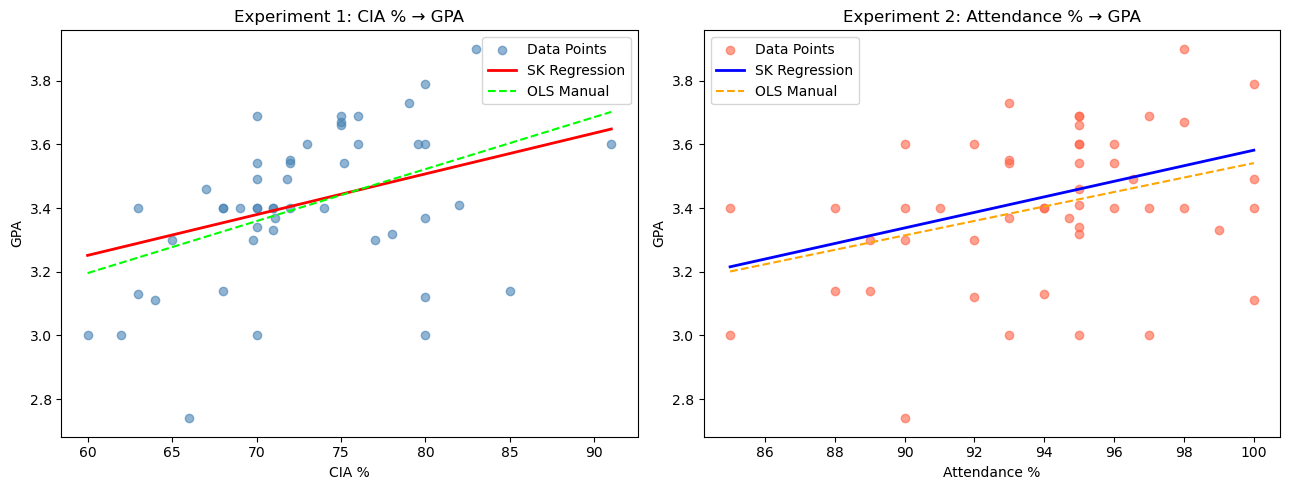

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Experiment 1
x_range1 = np.linspace(df['CIA_pct'].min(), df['CIA_pct'].max(), 100).reshape(-1, 1)
axes[0].scatter(df['CIA_pct'], df['GPA'], color='steelblue', alpha=0.6, label='Data Points')
axes[0].plot(x_range1, model1.predict(x_range1), color='red',   lw=2, label='SK Regression')
axes[0].plot(x_range1, m1_ols * x_range1 + b1_ols, color='lime', lw=1.5, ls='--', label='OLS Manual')
axes[0].set_xlabel('CIA %'); axes[0].set_ylabel('GPA')
axes[0].set_title('Experiment 1: CIA % → GPA')
axes[0].legend()

# Experiment 2
x_range2 = np.linspace(df['Attendance_pct'].min(), df['Attendance_pct'].max(), 100).reshape(-1, 1)
axes[1].scatter(df['Attendance_pct'], df['GPA'], color='tomato', alpha=0.6, label='Data Points')
axes[1].plot(x_range2, model2.predict(x_range2), color='blue',  lw=2, label='SK Regression')
axes[1].plot(x_range2, m2_ols * x_range2 + b2_ols, color='orange', lw=1.5, ls='--', label='OLS Manual')
axes[1].set_xlabel('Attendance %'); axes[1].set_ylabel('GPA')
axes[1].set_title('Experiment 2: Attendance % → GPA')
axes[1].legend()

plt.tight_layout()
plt.savefig('regression_lines.png', dpi=120)
plt.show()



Regression Line Plots

The scatter plots now overlay the regression lines from both methods:
Red and Blue solid line→ Scikit-learn fit (on training split)
Green and Orange dashed line→ Manual OLS fit (on full dataset)

The lines nearly coincide, visually confirming the equivalence of both approaches.

In [25]:
import pickle

# Save parameters
params = {
    'exp1': {'slope': slope1_sk, 'intercept': intercept1_sk},
    'exp2': {'slope': slope2_sk, 'intercept': intercept2_sk}
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(params, f)
print("Parameters saved to linear_regression_weights.pkl")

# Load parameters
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)
print("Loaded parameters:", loaded_params)

# Use loaded parameters for prediction
new_CIA = np.array([[75]])
loaded_slope = loaded_params['exp1']['slope']
loaded_intercept = loaded_params['exp1']['intercept']
pred = loaded_slope * new_CIA + loaded_intercept
print(f"Predicted GPA for CIA%=75: {pred[0][0]:.4f}")

Parameters saved to linear_regression_weights.pkl
Loaded parameters: {'exp1': {'slope': np.float64(0.012799678459146441), 'intercept': np.float64(2.4833799073893714)}, 'exp2': {'slope': np.float64(0.02440993165985645), 'intercept': np.float64(1.1406546355016682)}}
Predicted GPA for CIA%=75: 3.4434



Parameter Saving with Pickle

Once a model is trained, re-training every time is inefficient. pickle serializes Python objects (including slope and intercept values) to a binary file. The saved file can be loaded later to make predictions without re-training.

Steps demonstrated:
1. Save slope & intercept for both experiments ->linear_regression_weights.pkl
2. Load the pickle file back into memory
3. Use the loaded parameters to predict GPA for a new CIA% value



Conclusion:
Both CIA% and Attendance% show a weak positive relationship with GPA — higher values tend toward slightly higher GPA.  
Low R² is expected for a small 49-sample class dataset where GPA depends on many factors beyond these two predictors.  
Scikit-learn and manual OLS produce mathematically equivalent results when applied to the same dataset, confirming the theoretical foundation of linear regression.